# GCN Baseline — QM9 HOMO-LUMO Gap Prediction

**Model:** Graph Convolutional Network
**Task:** Predict HOMO-LUMO gap from bond topology  
**Metric:** Mean Absolute Error (MAE) in eV  

This notebook trains the GCN baseline on the QM9 dataset. It uses only bond
topology (`data.x` + `data.edge_index`) — no 3D coordinates.

## 1. Environment Setup

In [1]:
# Install dependencies (pinned for reproducibility)
!pip install -q torch==2.2.0 torchvision==0.17.0 --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch-geometric==2.5.0
!pip install -q torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.2.0+cu121.html
!pip install -q wandb matplotlib seaborn scikit-learn python-dotenv numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.5 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 118.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 145.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 49.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 10.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━

In [2]:
# Imports
import os
import json
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import wandb
from dotenv import load_dotenv
from google.colab import drive

import torch
import torch.nn as nn

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool


In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.2.0+cu121
CUDA available: True
GPU: NVIDIA L4
GPU Memory: 23.7 GB


In [4]:
# Mount Google Drive for persistent storage
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/24788-miniproject'
CHECKPOINT_DIR = os.path.join(DRIVE_DIR, 'gcn_checkpoints')
CONFIG_DIR = os.path.join(DRIVE_DIR, 'gcn_configs')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Configs: {CONFIG_DIR}")

Mounted at /content/drive
Checkpoints: /content/drive/MyDrive/24788-miniproject/gcn_checkpoints
Configs: /content/drive/MyDrive/24788-miniproject/gcn_configs


In [5]:
# W&B login
load_dotenv("/content/drive/MyDrive/24788-miniproject/.env")
api_key = os.environ.get("WANDB_API_KEY")

if api_key:
    wandb.login(key=api_key)
else:
    raise ValueError("WANDB_API_KEY not found. Add it to Colab Secrets or /content/drive/MyDrive/24788-miniproject/.env")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: anindith-ram (anindith-ram-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Configuration

In [6]:
CONFIG = {
    # Data
    "target_idx": 4,           # HOMO-LUMO gap
    "batch_size": 64,
    "seed": 42,
    "train_size": 110000,
    "val_size": 10000,
    "test_size": 10000,
    # Model
    "model": "GCN",
    "in_channels": 11,
    "hidden_channels": 128,
    "num_layers": 4,
    "dropout": 0.1,
    # Training
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "max_epochs": 300,
    "patience": 25,
    "scheduler_factor": 0.5,
    "scheduler_patience": 10,
    "min_lr": 1e-6,
    "grad_clip": 10.0,
}

# Save config to Drive
config_path = os.path.join(CONFIG_DIR, 'gcn_config.json')
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"Config saved to {config_path}")
print(json.dumps(CONFIG, indent=2))

Config saved to /content/drive/MyDrive/24788-miniproject/gcn_configs/gcn_config.json
{
  "target_idx": 4,
  "batch_size": 64,
  "seed": 42,
  "train_size": 110000,
  "val_size": 10000,
  "test_size": 10000,
  "model": "GCN",
  "in_channels": 11,
  "hidden_channels": 128,
  "num_layers": 4,
  "dropout": 0.1,
  "lr": 0.001,
  "weight_decay": 1e-05,
  "max_epochs": 300,
  "patience": 25,
  "scheduler_factor": 0.5,
  "scheduler_patience": 10,
  "min_lr": 1e-06,
  "grad_clip": 10.0
}


## 3. Data Pipeline

In [7]:
# Set all random seeds
def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

# Load QM9
dataset = QM9(root='./data/QM9')
print(f"Dataset size: {len(dataset)}")
print(f"Sample data fields: {dataset[0]}")
print(f"Target shape: {dataset[0].y.shape}")
print(f"HOMO-LUMO gap (sample 0): {dataset[0].y[0, CONFIG['target_idx']]:.4f} eV")

Extracting data/QM9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.


Dataset size: 130831
Sample data fields: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])
Target shape: torch.Size([1, 19])
HOMO-LUMO gap (sample 0): 13.7363 eV


Done!


In [8]:
# Deterministic split: 110k / 10k / 10k
torch.manual_seed(CONFIG['seed'])
perm = torch.randperm(len(dataset))

train_idx = perm[:CONFIG['train_size']]
val_idx = perm[CONFIG['train_size']:CONFIG['train_size'] + CONFIG['val_size']]
test_idx = perm[CONFIG['train_size'] + CONFIG['val_size']:CONFIG['train_size'] + CONFIG['val_size'] + CONFIG['test_size']]

train_dataset = dataset[train_idx]
val_dataset = dataset[val_idx]
test_dataset = dataset[test_idx]

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 110000 | Val: 10000 | Test: 10000


In [9]:
# Compute target normalization statistics from training set
TARGET_IDX = CONFIG['target_idx']
train_targets = torch.cat([data.y[:, TARGET_IDX] for data in train_dataset])
target_mean = train_targets.mean().item()
target_std = train_targets.std().item()

print(f"Target {TARGET_IDX} (HOMO-LUMO gap):")
print(f"  Training mean: {target_mean:.4f} eV")
print(f"  Training std:  {target_std:.4f} eV")
print(f"  Training range: [{train_targets.min():.4f}, {train_targets.max():.4f}] eV")

Target 4 (HOMO-LUMO gap):
  Training mean: 6.8580 eV
  Training std:  1.2831 eV
  Training range: [0.6694, 16.9282] eV


In [10]:
class NormalizeTarget:
    """Normalize a single target column to zero-mean, unit-variance."""
    def __init__(self, mean: float, std: float, idx: int):
        self.mean = mean
        self.std = std
        self.idx = idx

    def __call__(self, data):
        data.y_norm = (data.y[:, self.idx] - self.mean) / self.std
        return data

transform = NormalizeTarget(target_mean, target_std, TARGET_IDX)

# Apply normalization transform
train_dataset_t = [transform(d) for d in train_dataset]
val_dataset_t = [transform(d) for d in val_dataset]
test_dataset_t = [transform(d) for d in test_dataset]

# Create DataLoaders
train_loader = DataLoader(train_dataset_t, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset_t, batch_size=CONFIG['batch_size'])
test_loader = DataLoader(test_dataset_t, batch_size=CONFIG['batch_size'])

# Sanity check
batch = next(iter(train_loader))
print(f"Batch: {batch}")
print(f"x shape: {batch.x.shape}")
print(f"edge_index shape: {batch.edge_index.shape}")
print(f"y_norm sample: {batch.y_norm[:5]}")

Batch: DataBatch(x=[1153, 11], edge_index=[2, 2382], edge_attr=[2382, 4], y=[64, 19], pos=[1153, 3], idx=[64], name=[64], z=[1153], y_norm=[64], batch=[1153], ptr=[65])
x shape: torch.Size([1153, 11])
edge_index shape: torch.Size([2, 2382])
y_norm sample: tensor([-0.6368,  1.0577,  1.6748, -0.7662,  0.2539])


## 4. Model Definition

In [11]:
class GCNBaseline(nn.Module):
    """
    Graph Convolutional Network for molecular property prediction.
    Operates on bond topology only — ignores 3D coordinates.

    Architecture:
        Input(11) -> Linear(hidden) -> [GCNConv -> BN -> ReLU -> Dropout] x L
        -> GlobalMeanPool -> MLP(hidden -> hidden//2 -> 1)

    Reference: Kipf & Welling, ICLR 2017.
    """
    def __init__(self, in_channels: int = 11, hidden_channels: int = 128,
                 num_layers: int = 4, dropout: float = 0.1):
        super().__init__()

        # Input projection: map raw node features to hidden dim
        self.input_proj = nn.Linear(in_channels, hidden_channels)

        # GCN message-passing layers
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.dropout = nn.Dropout(dropout)

        # Prediction MLP
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Project input features
        x = self.input_proj(x)

        # Message passing
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = torch.relu(x)
            x = self.dropout(x)

        # Graph-level readout
        x = global_mean_pool(x, batch)  # [num_graphs, hidden]

        # Predict scalar property
        return self.mlp(x).squeeze(-1)  # [num_graphs]

    def get_embeddings(self, data):
        """Extract graph-level embeddings before the prediction MLP (for t-SNE)."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.input_proj(x)
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = torch.relu(x)
            x = self.dropout(x)
        return global_mean_pool(x, batch)  # [num_graphs, hidden]

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = GCNBaseline(
    in_channels=CONFIG['in_channels'],
    hidden_channels=CONFIG['hidden_channels'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")
print(model)

## 5. Training Utilities

In [13]:
def train_epoch(model: nn.Module, loader: DataLoader,
                optimizer: torch.optim.Optimizer, device: torch.device,
                grad_clip: float = 10.0) -> float:
    """Train for one epoch. Returns average normalized MAE loss."""
    model.train()
    total_loss = 0.0
    num_samples = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        loss = nn.functional.l1_loss(pred, data.y_norm)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        num_samples += data.num_graphs
    return total_loss / num_samples


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device,
             target_mean: float, target_std: float, target_idx: int) -> float:
    """Evaluate MAE in original eV units (de-normalized)."""
    model.eval()
    abs_errors = []
    for data in loader:
        data = data.to(device)
        pred_norm = model(data)
        # De-normalize predictions back to eV
        pred_eV = pred_norm * target_std + target_mean
        true_eV = data.y[:, target_idx]
        abs_errors.append((pred_eV - true_eV).abs())
    return torch.cat(abs_errors).mean().item()


def save_checkpoint(model: nn.Module, optimizer: torch.optim.Optimizer,
                    scheduler, epoch: int, val_mae: float,
                    target_mean: float, target_std: float,
                    path: str, config: dict) -> None:
    """Save full training state for resumption."""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_mae': val_mae,
        'target_mean': target_mean,
        'target_std': target_std,
        'config': config,
    }, path)


def load_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer,
                    scheduler, device: torch.device) -> dict:
    """Load training state for resumption."""
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    return ckpt

## 6. Training Loop

In [ ]:
# Set up optimizer and scheduler
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=CONFIG['scheduler_factor'],
    patience=CONFIG['scheduler_patience'],
    min_lr=CONFIG['min_lr']
)

# Resume from checkpoint if available
BEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, 'gcn_best.pt')
LATEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, 'gcn_latest.pt')

start_epoch = 1
best_val_mae = float('inf')
patience_counter = 0

if os.path.exists(LATEST_CKPT_PATH):
    print("Resuming from latest checkpoint...")
    ckpt = load_checkpoint(LATEST_CKPT_PATH, model, optimizer, scheduler, device)
    start_epoch = ckpt['epoch'] + 1
    best_val_mae = ckpt['val_mae']
    print(f"  Resumed at epoch {start_epoch}, best val MAE: {best_val_mae:.4f} eV")
else:
    print("Starting training from scratch.")

Resuming from latest checkpoint...
  Resumed at epoch 263, best val MAE: 0.1496 eV


In [19]:
# Initialize W&B
wandb.init(
    project='24788-miniproject',
    name='GCN-baseline',
    config=CONFIG,
    resume='allow'
)
wandb.watch(model, log='gradients', log_freq=100)

In [20]:
print(f"Training GCN from epoch {start_epoch} to {CONFIG['max_epochs']}")
print(f"Best val MAE so far: {best_val_mae:.4f} eV")
print("=" * 70)

for epoch in range(start_epoch, CONFIG['max_epochs'] + 1):
    t0 = time.time()

    # Train
    train_loss = train_epoch(model, train_loader, optimizer, device,
                             grad_clip=CONFIG['grad_clip'])

    # Evaluate (MAE in eV)
    val_mae = evaluate(model, val_loader, device, target_mean, target_std, TARGET_IDX)

    # Step scheduler
    scheduler.step(val_mae)
    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - t0

    # Log to W&B
    wandb.log({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_mae_eV': val_mae,
        'learning_rate': current_lr,
        'epoch_time_s': epoch_time,
    })

    # Checkpointing
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_counter = 0
        save_checkpoint(model, optimizer, scheduler, epoch, best_val_mae,
                        target_mean, target_std, BEST_CKPT_PATH, CONFIG)
    else:
        patience_counter += 1

    # Always save latest for resumption
    save_checkpoint(model, optimizer, scheduler, epoch, best_val_mae,
                    target_mean, target_std, LATEST_CKPT_PATH, CONFIG)

    # Print progress
    if epoch % 5 == 0 or epoch == start_epoch or patience_counter == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
              f"Val MAE: {val_mae:.4f} eV | Best: {best_val_mae:.4f} eV | "
              f"LR: {current_lr:.2e} | Patience: {patience_counter}/{CONFIG['patience']} | "
              f"Time: {epoch_time:.1f}s")

    # Early stopping
    if patience_counter >= CONFIG['patience']:
        print(f"\nEarly stopping at epoch {epoch}. Best val MAE: {best_val_mae:.4f} eV")
        break

print("\nTraining complete!")
print(f"Best validation MAE: {best_val_mae:.4f} eV")
wandb.finish()

Training GCN from epoch 1 to 300
Best val MAE so far: inf eV
Epoch 001 | Train Loss: 0.3532 | Val MAE: 0.3393 eV | Best: 0.3393 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 23.5s
Epoch 002 | Train Loss: 0.2768 | Val MAE: 0.2999 eV | Best: 0.2999 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 22.8s
Epoch 003 | Train Loss: 0.2571 | Val MAE: 0.2792 eV | Best: 0.2792 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 22.9s
Epoch 004 | Train Loss: 0.2478 | Val MAE: 0.2723 eV | Best: 0.2723 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 22.8s
Epoch 005 | Train Loss: 0.2394 | Val MAE: 0.2681 eV | Best: 0.2681 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 22.8s
Epoch 006 | Train Loss: 0.2316 | Val MAE: 0.2479 eV | Best: 0.2479 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 22.8s
Epoch 008 | Train Loss: 0.2216 | Val MAE: 0.2411 eV | Best: 0.2411 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 23.5s
Epoch 010 | Train Loss: 0.2129 | Val MAE: 0.2355 eV | Best: 0.2355 eV | LR: 1.00e-03 | Patience: 0/25 | Time: 22.8s
Epoch 011 |

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█
epoch_time_s,▄▆▇█▇▆▅▅▅█▅▆▅▆▇▆▅▇▇▆▇▅▆▃▅█▇▃▂▅▅▄▇▄▃▅▁▁▃▂
learning_rate,███████████████▄▄▄▄▄▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae_eV,██▇▆▆▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,262
epoch_time_s,22.70969
learning_rate,0.0
train_loss,0.14857
val_mae_eV,0.15038


## 7. Test Set Evaluation

In [24]:
# Load best checkpoint and evaluate on test set
print("Loading best checkpoint for test evaluation...")
ckpt = torch.load(BEST_CKPT_PATH, map_location=device)

model_eval = GCNBaseline(
    in_channels=CONFIG['in_channels'],
    hidden_channels=CONFIG['hidden_channels'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
).to(device)
model_eval.load_state_dict(ckpt['model_state_dict'])

test_mae = evaluate(model_eval, test_loader, device,
                    ckpt['target_mean'], ckpt['target_std'], TARGET_IDX)
val_mae = evaluate(model_eval, val_loader, device,
                   ckpt['target_mean'], ckpt['target_std'], TARGET_IDX)

print(f"\n{'='*50}")
print(f"  GCN Baseline Results")
print(f"{'='*50}")
print(f"  Best epoch:     {ckpt['epoch']}")
print(f"  Val MAE:        {val_mae:.4f} eV")
print(f"  Test MAE:       {test_mae:.4f} eV")
print(f"  Parameters:     {sum(p.numel() for p in model_eval.parameters()):,}")
print(f"{'='*50}")

Loading best checkpoint for test evaluation...

  GCN Baseline Results
  Best epoch:     237
  Val MAE:        0.1496 eV
  Test MAE:       0.1532 eV
  Parameters:     76,929


## 8. Prediction Visualization

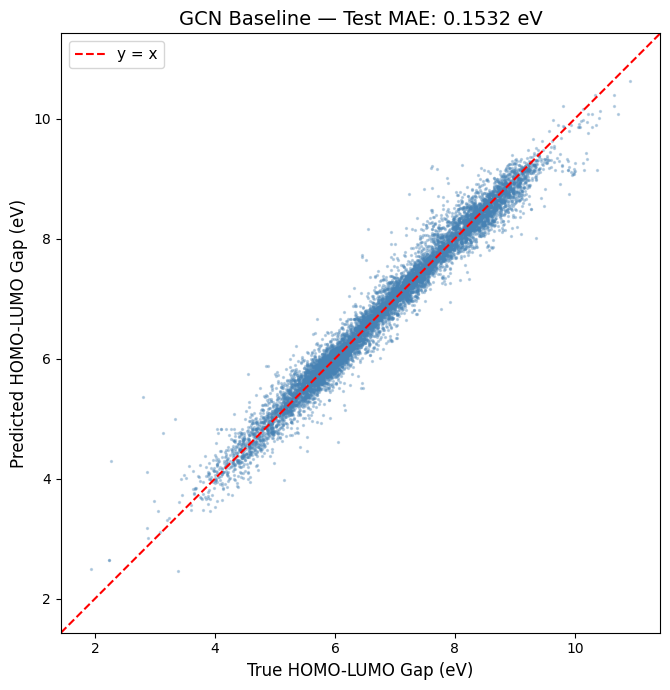

Figure saved to /content/drive/MyDrive/24788-miniproject/figures/gcn_pred_vs_true.png


In [ ]:
@torch.no_grad()
def get_predictions(model: nn.Module, loader: DataLoader, device: torch.device,
                    target_mean: float, target_std: float,
                    target_idx: int) -> tuple:
    """Get de-normalized predictions and true values."""
    model.eval()
    all_preds, all_trues = [], []
    for data in loader:
        data = data.to(device)
        pred_norm = model(data)
        pred_eV = pred_norm * target_std + target_mean
        true_eV = data.y[:, target_idx]
        all_preds.append(pred_eV.cpu())
        all_trues.append(true_eV.cpu())
    return torch.cat(all_preds).detach().cpu().numpy(), torch.cat(all_trues).detach().cpu().numpy()


preds, trues = get_predictions(model_eval, test_loader, device,
                                ckpt['target_mean'], ckpt['target_std'], TARGET_IDX)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(trues, preds, s=2, alpha=0.3, c='steelblue')
lims = [min(trues.min(), preds.min()) - 0.5, max(trues.max(), preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Ground Truth HOMO-LUMO Gap (eV)', fontsize=12)
ax.set_ylabel('Predicted HOMO-LUMO Gap (eV)', fontsize=12)
ax.set_title(f'GCN Baseline — Test MAE: {test_mae:.4f} eV', fontsize=14)
ax.legend(fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()

fig_path = os.path.join(DRIVE_DIR, 'figures')
os.makedirs(fig_path, exist_ok=True)
plt.savefig(os.path.join(fig_path, 'gcn_pred_vs_true.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {fig_path}/gcn_pred_vs_true.png")

## 9. Embedding Extraction

In [ ]:
@torch.no_grad()
def extract_gcn_embeddings(
    model: torch.nn.Module,
    loader,
    device: torch.device,
    target_idx: int,
    max_samples: int | None = 2000,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Graph-level GCN embeddings [N, hidden_channels] via model.get_embeddings(),
    plus HOMO-LUMO gap in eV from data.y[:, target_idx].
    """
    model.eval()
    emb_chunks, y_chunks = [], []
    n_graphs = 0
    for data in loader:
        data = data.to(device)
        z = model.get_embeddings(data)
        y_eV = data.y[:, target_idx].float()
        emb_chunks.append(z.float().cpu())
        y_chunks.append(y_eV.cpu())
        n_graphs += data.num_graphs
        if max_samples is not None and n_graphs >= max_samples:
            break
    embeddings = torch.cat(emb_chunks, dim=0)
    labels_eV = torch.cat(y_chunks, dim=0)
    if max_samples is not None:
        embeddings = embeddings[:max_samples]
        labels_eV = labels_eV[:max_samples]
    return (np.array(embeddings.detach().cpu().tolist()), np.array(labels_eV.detach().cpu().tolist()))


BEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "gcn_best.pt")
ckpt = torch.load(BEST_CKPT_PATH, map_location=device, weights_only=False)

emb_model = GCNBaseline(
    in_channels=CONFIG["in_channels"],
    hidden_channels=CONFIG["hidden_channels"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
).to(device)

emb_model.load_state_dict(ckpt["model_state_dict"])
gcn_embeddings, gcn_labels_eV = extract_gcn_embeddings(
    emb_model, test_loader, device, TARGET_IDX, max_samples=2000
)

print("embeddings:", gcn_embeddings.shape, "| labels_eV:", gcn_labels_eV.shape)
print(f"gap range: [{gcn_labels_eV.min():.3f}, {gcn_labels_eV.max():.3f}] eV")

EMBED_DIR = os.path.join(DRIVE_DIR, "embeddings")
os.makedirs(EMBED_DIR, exist_ok=True)
np.save(os.path.join(EMBED_DIR, "gcn_embeddings.npy"), gcn_embeddings)
np.save(os.path.join(EMBED_DIR, "gcn_labels_eV.npy"), gcn_labels_eV)
print(f"Saved to {EMBED_DIR}/gcn_embeddings.npy")

embeddings: (2000, 128) | labels_eV: (2000,)
gap range: [2.797, 10.645] eV
Saved to /content/drive/MyDrive/24788-miniproject/embeddings/gcn_embeddings.npy


## 9. Summary

The GCN baseline has been trained and evaluated. Key outputs saved to Google Drive:
- **Best checkpoint:** `checkpoints/gcn_best.pt`
- **Latest checkpoint:** `checkpoints/gcn_latest.pt`
- **Config:** `configs/gcn_config.json`
- **Figure:** `figures/gcn_pred_vs_true.png`
- **Embeddings:** `embeddings/gcn_embeddings.npy`
- **W&B run:** `24788-miniproject/GCN-baseline`